In [1]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import ast
import math

In [2]:
def safe_literal_eval(val):
    if pd.isna(val):
        return None
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return None

In [3]:
contrib_2024 = pd.read_csv("../data/contributions/committees/corp_candidate_2024.csv")
cpac_hedging = pd.read_csv("../data/hedging/cpac_hedging_full_pe.csv")
cpac_hedging = cpac_hedging.loc[cpac_hedging["YEAR"] == 2024,]
cmte_info = cpac_hedging[["CMTE_ID", "HQ_State", "TRBC_Econ_Sector", "n_states", "n_cands"]].copy()

C:\Users\zih028\AppData\Local\Temp\ipykernel_2640\3860555214.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib_2024 = pd.read_csv("../data/contributions/committees/corp_candidate_2024.csv")


In [4]:
cmte_info["Sector"] = cmte_info["TRBC_Econ_Sector"].apply(safe_literal_eval)
cmte_info["Sector"] = cmte_info["Sector"].apply(lambda x: x[0] if isinstance(x, list) else None)
cmte_info.drop(columns = "TRBC_Econ_Sector", inplace=True)

In [5]:
cmte_cand = pd.crosstab(contrib_2024["CMTE_ID"], contrib_2024["CAND_ID"])

In [6]:
def compute_similarity_matrix(df, metric = 'cosine',binarize_threshold=0):
    if metric == 'cosine':
        sim = cosine_similarity(df)
    elif metric == 'jaccard':
        binary_df = (df > binarize_threshold).astype(int)
        dist = pairwise_distances(binary_df.values, metric='jaccard')
        sim = 1 - dist  # Convert distance to similarity
    else:
        raise ValueError(f"Unsupported similarity metric: {metric}")
    
    return pd.DataFrame(sim, index=df.index.copy(), columns=df.index.copy())

def build_network_df(sim_df):
    sim_df.index.name = "CMTE_1"
    sim_df.columns.name = "CMTE_2"
    edge_list = (
        sim_df.stack()
        .reset_index().
        rename(columns={0: "Similarity"})
    )
    return edge_list[edge_list["CMTE_1"] != edge_list["CMTE_2"]]

def add_characteristics(network_df, cmte_info):
    merged = network_df.merge(cmte_info, left_on="CMTE_1", right_on="CMTE_ID", how = "left")
    merged = merged.rename(columns={"HQ_State": "HQ_State_1", "Sector": "Sector_1", "n_states": "n_states_1", "n_cands": "n_cands_1"}).drop(columns=["CMTE_ID"])

    merged = merged.merge(cmte_info, left_on="CMTE_2", right_on="CMTE_ID", how="left")
    merged = merged.rename(columns={"HQ_State": "HQ_State_2", "Sector": "Sector_2", "n_states": "n_states_2", "n_cands": "n_cands_2"}).drop(columns=["CMTE_ID"])

    merged["same_state"] = merged["HQ_State_1"] == merged["HQ_State_2"]
    merged["same_sector"] = merged["Sector_1"] == merged["Sector_2"]
    
    return merged

def compare_similarity_by_group(network_df, colname="same_state"):
    group_true = network_df[network_df[colname]]["Similarity"]
    group_false = network_df[~network_df[colname]]["Similarity"]

    t_stat, p_value = ttest_ind(group_true, group_false, equal_var=False)

    result = {
        "group": colname,
        "mean_true": group_true.mean(),
        "mean_false": group_false.mean(),
        "t_stat": t_stat,
        "p_value": p_value
    }
    return result

def cohesion_by_category(network_df, category="state"):
    if category == "state":
        df = network_df[network_df["HQ_State_1"] == network_df["HQ_State_2"]].copy()
        df["Group"] = df["HQ_State_1"]
    elif category == "sector":
        df = network_df[network_df["Sector_1"] == network_df["Sector_2"]].copy()
        df["Group"] = df["Sector_1"]
    else:
        raise ValueError("category must be 'state' or 'sector'")

    return df.groupby("Group")["Similarity"].mean().sort_values(ascending=False)

In [7]:
sim_df = compute_similarity_matrix(cmte_cand, "cosine")
edges = build_network_df(sim_df)
network = add_characteristics(edges, cmte_info)
print(compare_similarity_by_group(network, "same_state"))
print(compare_similarity_by_group(network, "same_sector"))

state_cohesion = cohesion_by_category(network, category="state")
sector_cohesion = cohesion_by_category(network, category="sector")

print(state_cohesion.head(10))
print(sector_cohesion)

{'group': 'same_state', 'mean_true': 0.1121425387180023, 'mean_false': 0.06546443893424893, 't_stat': 63.6922668024115, 'p_value': 0.0}
{'group': 'same_sector', 'mean_true': 0.09716994692632136, 'mean_false': 0.06286441290963411, 't_stat': 83.82345250416934, 'p_value': 0.0}
Group
ALASKA          0.550637
HAWAII          0.346106
OREGON          0.339902
IOWA            0.282899
OKLAHOMA        0.277379
NEBRASKA        0.263903
MINNESOTA       0.263170
MISSISSIPPI     0.258258
RHODE ISLAND    0.245002
NEVADA          0.217891
Name: Similarity, dtype: float64
Group
Healthcare                                    0.162748
Energy                                        0.140379
Real Estate                                   0.134167
Financials                                    0.111156
Utilities                                     0.098441
Technology                                    0.081527
Consumer Non-Cyclicals                        0.076205
Industrials                                  

In [8]:
sector_cohesion

Group
Healthcare                                    0.162748
Energy                                        0.140379
Real Estate                                   0.134167
Financials                                    0.111156
Utilities                                     0.098441
Technology                                    0.081527
Consumer Non-Cyclicals                        0.076205
Industrials                                   0.073883
Basic Materials                               0.068992
Academic & Educational Services               0.068642
Consumer Cyclicals                            0.065525
Institutions, Associations & Organizations    0.019933
Name: Similarity, dtype: float64

In [9]:
network["n_states_avg"] = (network["n_states_1"] + network["n_states_2"]) / 2
network["n_cands_avg"] = (network["n_cands_1"] + network["n_cands_2"]) / 2

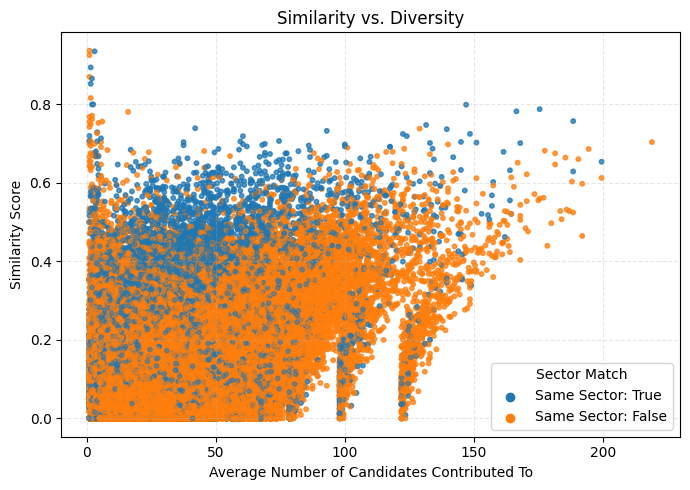

In [10]:
colors = network["same_sector"].map({True: 'tab:blue', False: 'tab:orange'})
plt.figure(figsize=(7, 5))
plt.scatter(
    network["n_cands_avg"],
    network["Similarity"],
    c=colors,
    alpha=0.5,
    s=10,
    label=None
)
for value, color in {True: 'tab:blue', False: 'tab:orange'}.items():
    plt.scatter([], [], c=color, label=f"Same Sector: {value}")

plt.xlabel("Average Number of Candidates Contributed To")
plt.ylabel("Similarity Score")
plt.title("Similarity vs. Diversity")
plt.legend(title="Sector Match", loc="lower right")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

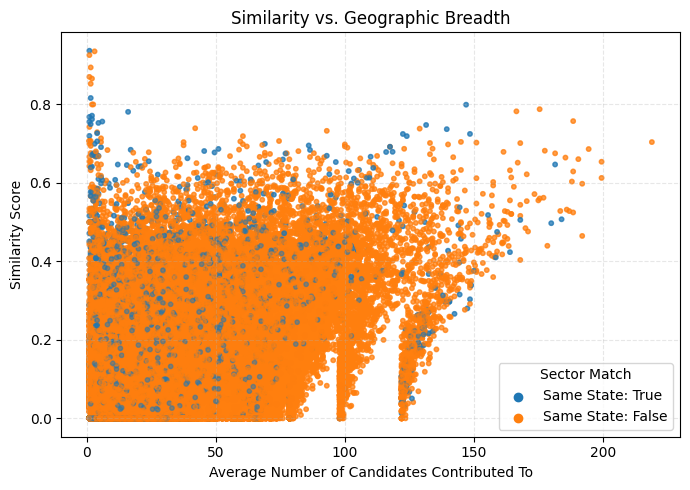

In [11]:
colors = network["same_state"].map({True: 'tab:blue', False: 'tab:orange'})
plt.figure(figsize=(7, 5))
plt.scatter(
    network["n_cands_avg"],
    network["Similarity"],
    c=colors,
    alpha=0.5,
    s=10,
    label=None
)
for value, color in {True: 'tab:blue', False: 'tab:orange'}.items():
    plt.scatter([], [], c=color, label=f"Same State: {value}")

plt.xlabel("Average Number of Candidates Contributed To")
plt.ylabel("Similarity Score")
plt.title("Similarity vs. Geographic Breadth")
plt.legend(title="Sector Match", loc="lower right")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
network

,CMTE_1,CMTE_2,Similarity,HQ_State_1,n_states_1,n_cands_1,Sector_1,HQ_State_2,n_states_2,n_cands_2,Sector_2,same_state,same_sector,n_states_avg,n_cands_avg
0,C00000059,C00002790,0.135015,MISSOURI,5.0,7.0,Consumer Cyclicals,MISSOURI,8.0,9.0,Basic Materials,True,False,6.5,8.0
1,C00000059,C00003251,0.145065,MISSOURI,5.0,7.0,Consumer Cyclicals,NaN,NaN,NaN,NaN,False,False,NaN,NaN
2,C00000059,C00004952,0.000000,MISSOURI,5.0,7.0,Consumer Cyclicals,MISSISSIPPI,1.0,4.0,"Institutions, Associations & Organizations",False,False,3.0,5.5
3,C00000059,C00007070,0.031665,MISSOURI,5.0,7.0,Consumer Cyclicals,TEXAS,12.0,21.0,Technology,False,False,8.5,14.0
4,C00000059,C00007948,0.011679,MISSOURI,5.0,7.0,Consumer Cyclicals,WASHINGTON,16.0,32.0,Real Estate,False,False,10.5,19.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812697,C00890566,C00882001,0.000000,ALABAMA,NaN,NaN,Industrials,FLORIDA,8.0,15.0,Industrials,False,True,NaN,NaN
812698,C00890566,C00882068,0.000000,ALABAMA,NaN,NaN,Industrials,CALIFORNIA,2.0,2.0,Healthcare,False,False,NaN,NaN
812699,C00890566,C00883645,0.000000,ALABAMA,NaN,NaN,Industrials,ALABAMA,1.0,1.0,Technology,True,False,NaN,NaN
812700,C00890566,C00884767,0.000000,ALABAMA,NaN,NaN,Industrials,CALIFORNIA,1.0,1.0,Technology,False,False,NaN,NaN


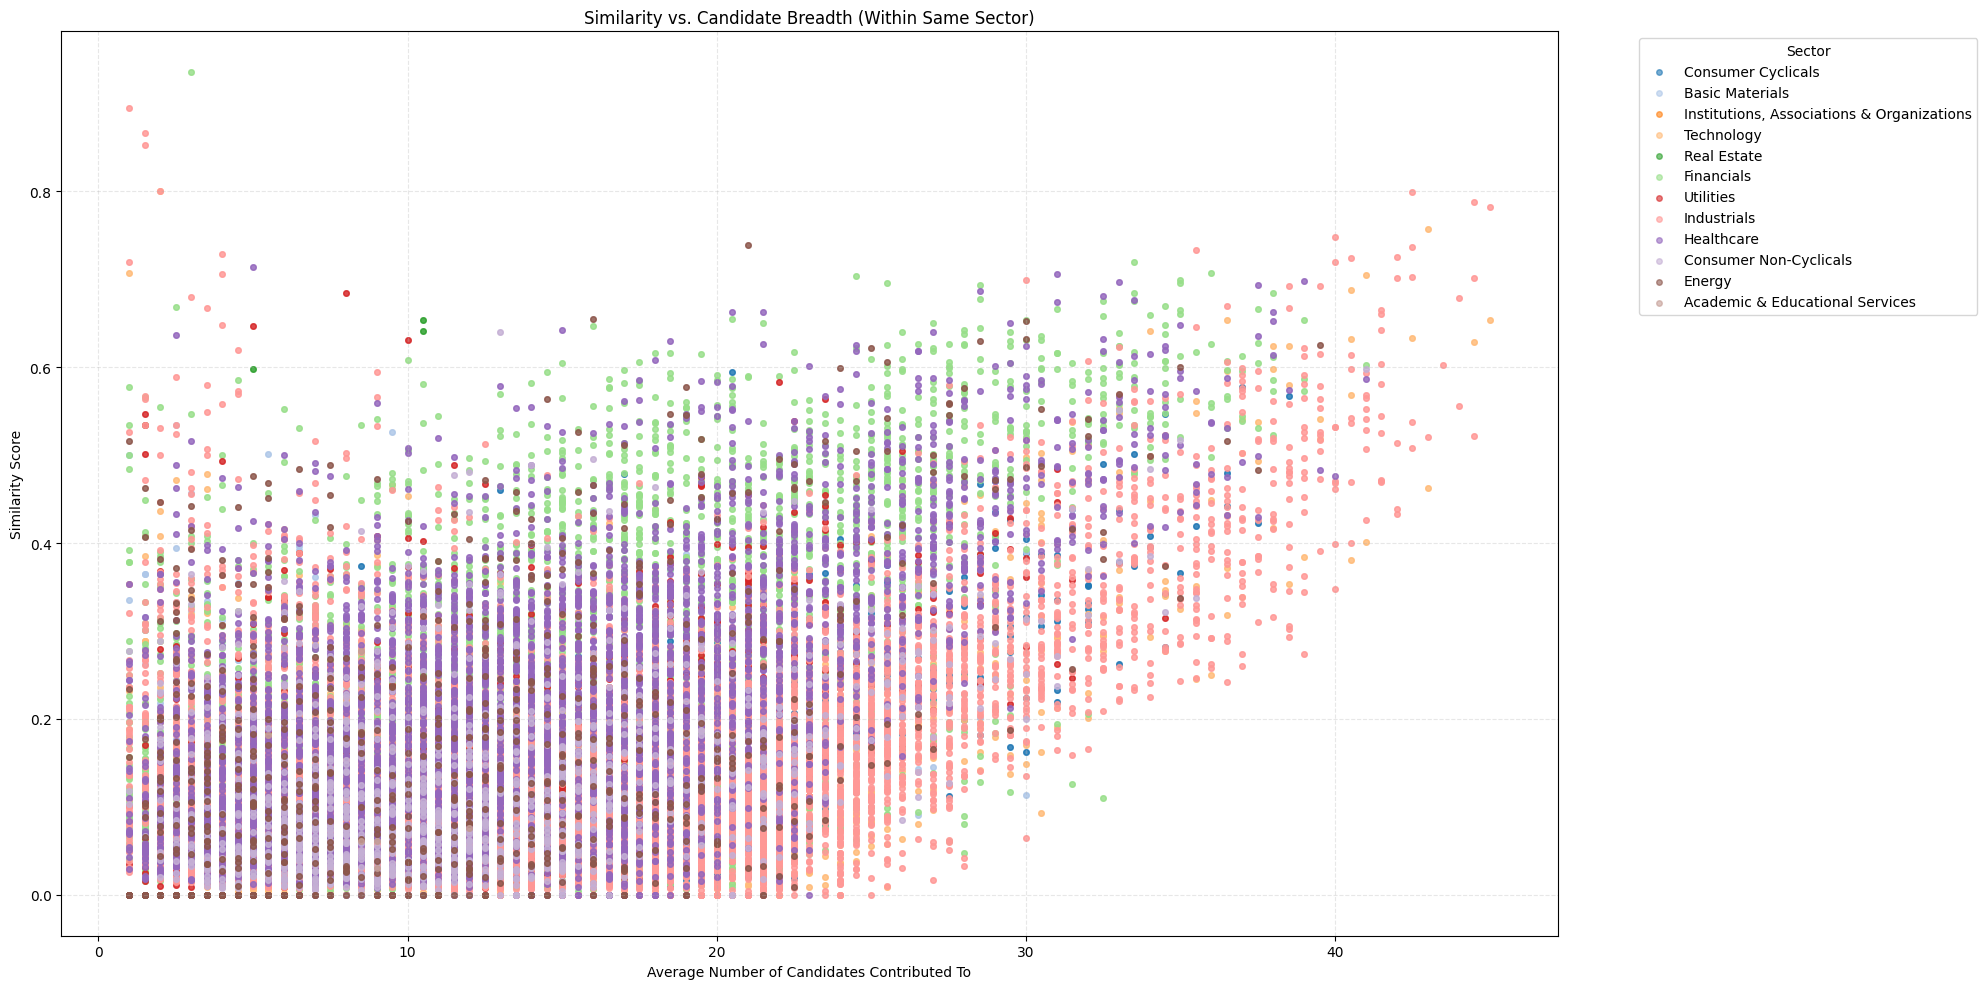

In [ ]:
same_sector = network.loc[network["same_sector"] == True,].copy()

unique_sectors = same_sector["Sector_1"].unique()
sector_colors = {sector: color for sector, color in zip(unique_sectors, plt.cm.tab20.colors)}

same_sector['color'] = same_sector['Sector_1'].map(sector_colors)

plt.figure(figsize=(20, 10))
for sector in unique_sectors:
    subset = same_sector[same_sector["Sector_1"] == sector]
    plt.scatter(
        subset["n_states_avg"],
        subset["Similarity"],
        label=sector,
        color=sector_colors[sector],
        alpha=0.6,
        s=12
    )

plt.xlabel("Average Number of Candidates Contributed To")
plt.ylabel("Similarity Score")
plt.title("Similarity vs. Candidate Breadth (Within Same Sector)")
plt.legend(title="Sector", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

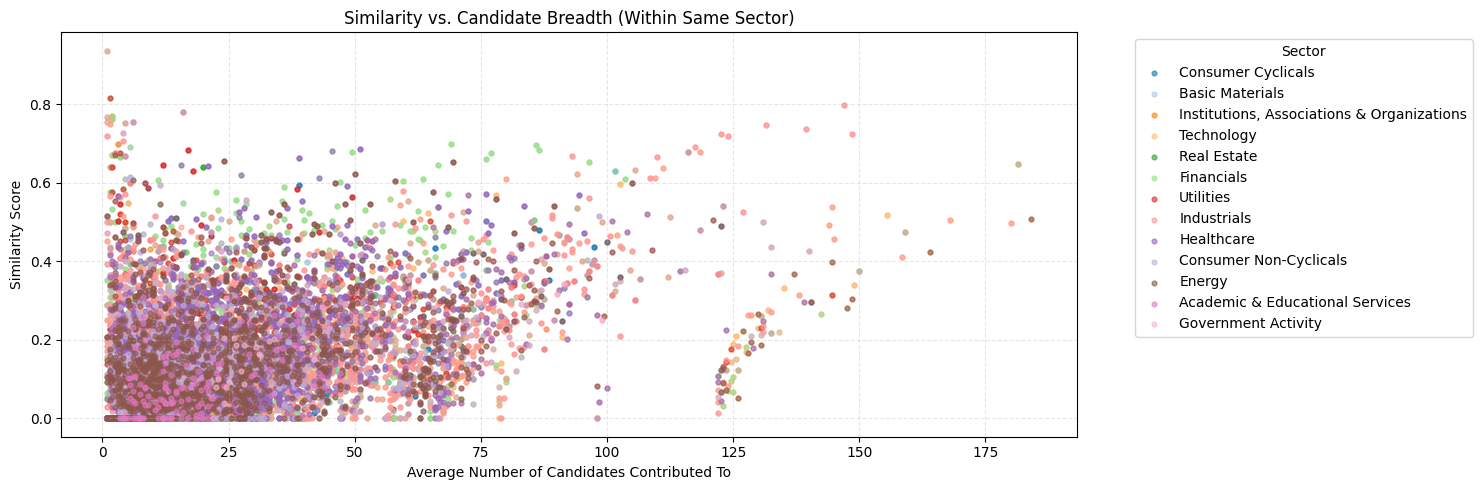

In [16]:
same_state = network.loc[network["same_state"] == True,].copy()

unique_sectors = same_state["Sector_1"].unique()
sector_colors = {sector: color for sector, color in zip(unique_sectors, plt.cm.tab20.colors)}

same_state['color'] = same_state['Sector_1'].map(sector_colors)

plt.figure(figsize=(15, 5))
for sector in unique_sectors:
    subset = same_state[same_state["Sector_1"] == sector]
    plt.scatter(
        subset["n_cands_avg"],
        subset["Similarity"],
        label=sector,
        color=sector_colors[sector],
        alpha=0.6,
        s=12
    )

plt.xlabel("Average Number of Candidates Contributed To")
plt.ylabel("Similarity Score")
plt.title("Similarity vs. Candidate Breadth (Within Same Sector)")
plt.legend(title="Sector", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
cpac_balance = cpac_hedging[["CMTE_ID", "balance_count", "balance_amount"]]
cpac_balance = cpac_balance.dropna().reset_index(drop=True)

In [19]:
count_dist = pairwise_distances(cpac_balance[["balance_count"]])
count_dist = pd.DataFrame(count_dist, index=cpac_balance["CMTE_ID"].copy(), columns=cpac_balance["CMTE_ID"].copy())
count_dist.index.name = "CMTE_1"
count_dist.columns.name = "CMTE_2"
count_dist = (
    count_dist.stack()
    .reset_index()
    .rename(columns={0: "count_dist"})
)
count_dist = count_dist.loc[count_dist["CMTE_1"] != count_dist["CMTE_2"]].reset_index(drop=True)

amount_dist = pairwise_distances(cpac_balance[["balance_amount"]])
amount_dist = pd.DataFrame(amount_dist, index=cpac_balance["CMTE_ID"].copy(), columns=cpac_balance["CMTE_ID"].copy())
amount_dist.index.name = "CMTE_1"
amount_dist.columns.name = "CMTE_2"
amount_dist = (
    amount_dist.stack()
    .reset_index()
    .rename(columns={0: "amount_dist"})
)
amount_dist = amount_dist.loc[amount_dist["CMTE_1"] != amount_dist["CMTE_2"]].reset_index(drop=True)

In [20]:
count_dist

,CMTE_1,CMTE_2,count_dist
0,C00002790,C00007070,0.634921
1,C00002790,C00007948,0.590278
2,C00002790,C00008151,0.222222
3,C00002790,C00008474,0.421846
4,C00002790,C00008748,0.840278
...,...,...,...
599845,C00883645,C00864264,0.000000
599846,C00883645,C00866483,1.666667
599847,C00883645,C00880351,2.000000
599848,C00883645,C00881813,2.000000


In [21]:
network = network.merge(count_dist, how = "left", on = ["CMTE_1", "CMTE_2"])
network = network.merge(amount_dist, how = "left", on = ["CMTE_1", "CMTE_2"])
clean_network = network.dropna(subset=["Similarity", "count_dist", "amount_dist"])

In [22]:
from sklearn.linear_model import LinearRegression
from scipy import stats

def ols_summary(X, y):
    # Ensure X is DataFrame for column names
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=[f"x{i}" for i in range(X.shape[1])])

    # Fit model
    model = LinearRegression()
    model.fit(X, y)

    # Predictions and residuals
    y_pred = model.predict(X)
    residuals = y - y_pred

    # Degrees of freedom
    n = X.shape[0]
    p = X.shape[1]  # exclude intercept

    # Add intercept column to X for variance-covariance calculation
    X_with_intercept = np.column_stack([np.ones(n), X.values])

    # Estimate variance of residuals
    sse = np.sum(residuals**2)
    sigma_squared = sse / (n - p - 1)

    # Covariance matrix of beta
    XTX_inv = np.linalg.inv(X_with_intercept.T @ X_with_intercept)
    var_betas = sigma_squared * XTX_inv.diagonal()
    std_err = np.sqrt(var_betas)

    # t-stats and p-values
    coef = np.insert(model.coef_, 0, model.intercept_)
    t_stats = coef / std_err
    p_values = [2 * (1 - stats.t.cdf(np.abs(t), df=n - p - 1)) for t in t_stats]

    # Build table
    summary = pd.DataFrame({
        "Coefficient": coef,
        "Std. Error": std_err,
        "t value": t_stats,
        "Pr(>|t|)": p_values
    }, index=["Intercept"] + list(X.columns))

    # Add R-squared
    r_squared = model.score(X, y)

    print("R-squared:", round(r_squared, 4))
    return summary

In [23]:
same_sector = clean_network.loc[clean_network["same_sector"] == True,].copy()

unique_sectors = same_sector["Sector_1"].unique()

for sector in unique_sectors:
    subset = same_sector[same_sector["Sector_1"] == sector]
    X = subset[["Similarity"]]
    y = subset["amount_dist"]
    print(f"Sector {sector}")
    ols = ols_summary(X, y)
    print(ols)
    print("\n")


Sector Consumer Cyclicals
R-squared: 0.2078
            Coefficient  Std. Error    t value  Pr(>|t|)
Intercept      0.813922    0.014263  57.065288       0.0
Similarity    -1.811780    0.087414 -20.726413       0.0


Sector Basic Materials
R-squared: 0.056
            Coefficient  Std. Error    t value  Pr(>|t|)
Intercept      0.795888    0.013213  60.235994       0.0
Similarity    -1.352947    0.114572 -11.808730       0.0


Sector Institutions, Associations & Organizations
R-squared: 0.0469
            Coefficient  Std. Error   t value      Pr(>|t|)
Intercept      0.589119    0.066472  8.862673  1.289144e-09
Similarity    -1.476256    1.257496 -1.173965  2.502981e-01


Sector Technology
R-squared: 0.107
            Coefficient  Std. Error    t value  Pr(>|t|)
Intercept      0.831141    0.009186  90.476470       0.0
Similarity    -1.359518    0.058210 -23.355601       0.0


Sector Real Estate
R-squared: 0.1414
            Coefficient  Std. Error   t value      Pr(>|t|)
Intercept      

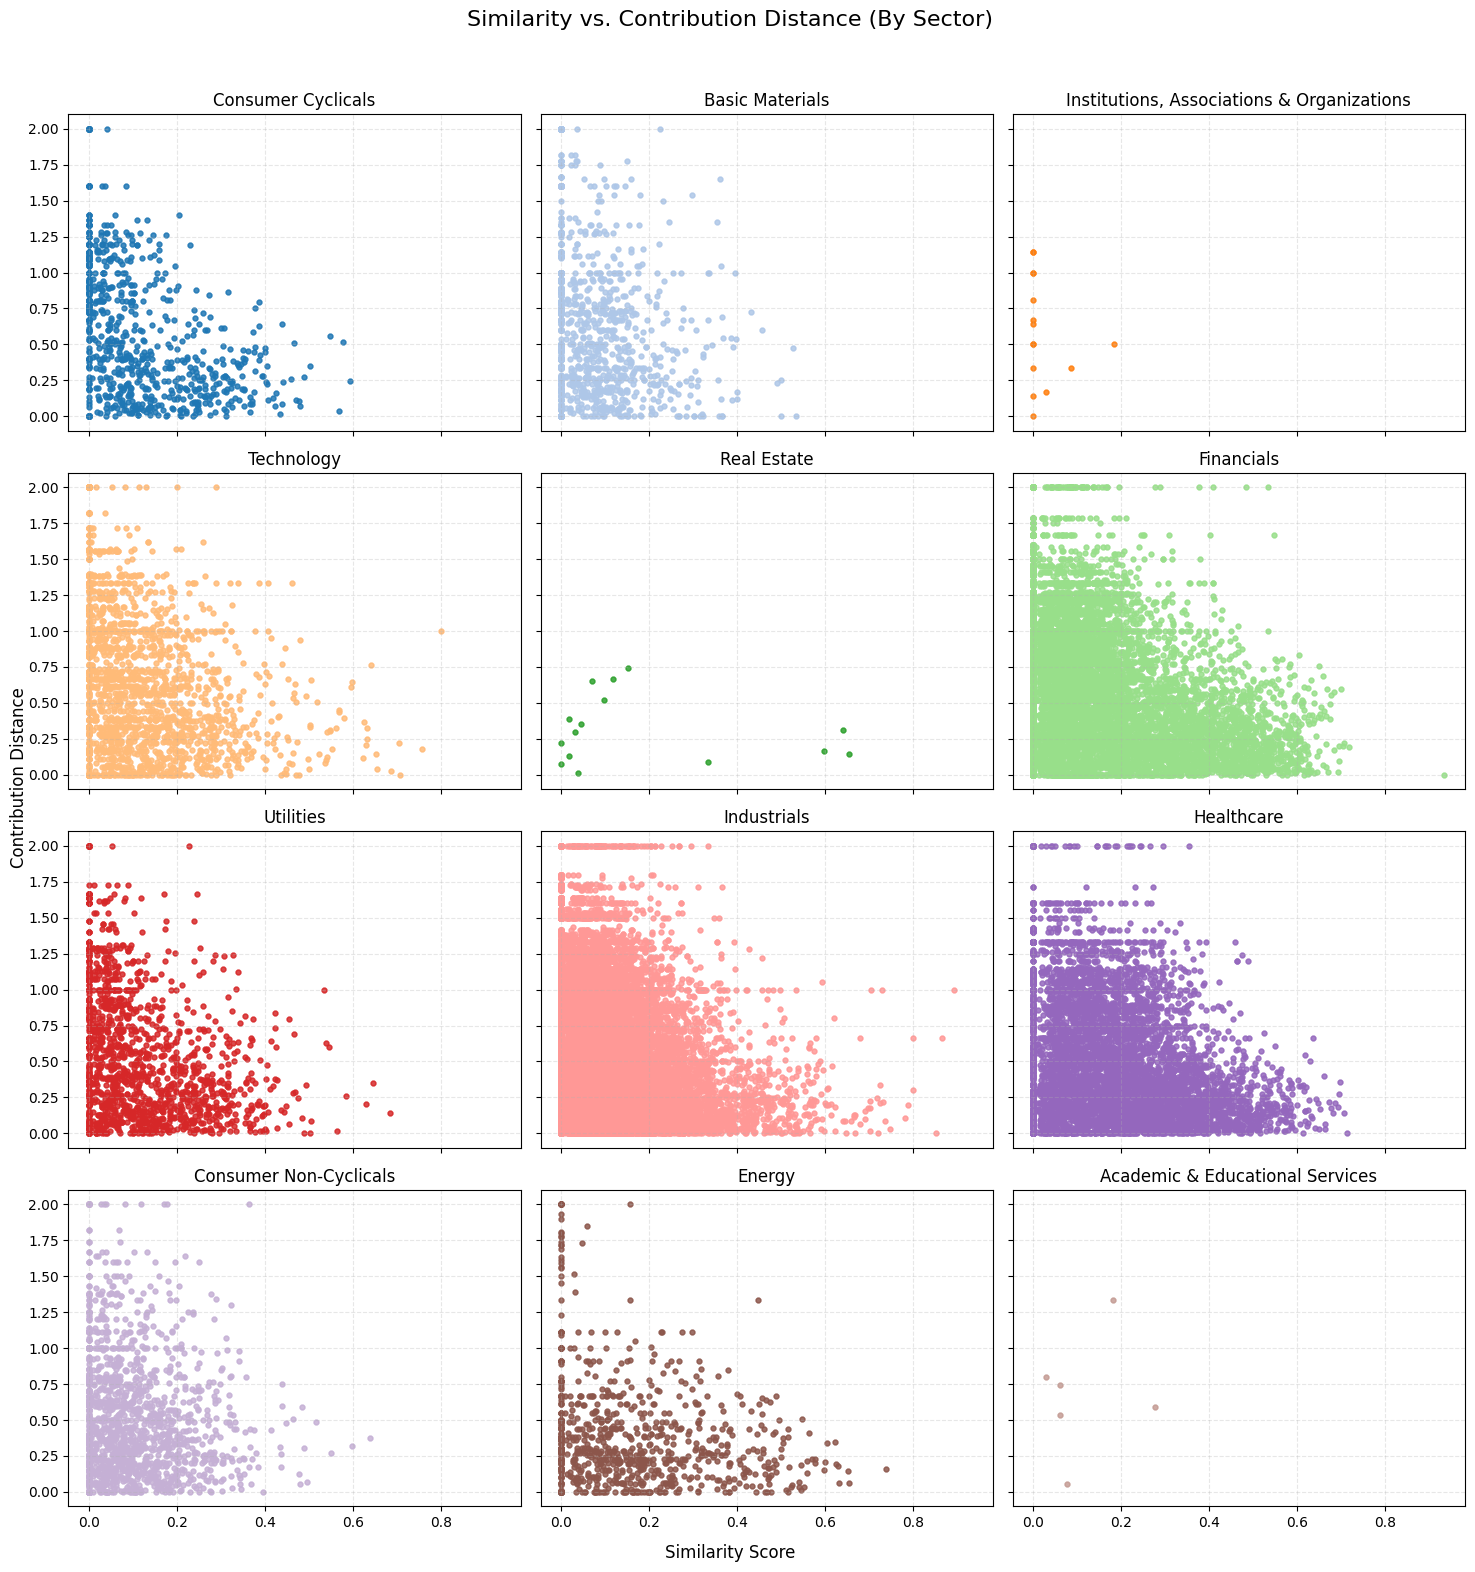

In [24]:
# Get unique sectors
unique_sectors = same_sector["Sector_1"].unique()
n_sectors = len(unique_sectors)

# Auto-determine subplot grid shape (e.g., 3 columns)
n_cols = 3
n_rows = math.ceil(n_sectors / n_cols)

# Set up the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to 1D for easier iteration

# Assign colors
sector_colors = {sector: color for sector, color in zip(unique_sectors, plt.cm.tab20.colors)}

# Plot each sector in its own subplot
for i, sector in enumerate(unique_sectors):
    ax = axes[i]
    subset = same_sector[same_sector["Sector_1"] == sector]
    ax.scatter(
        subset["Similarity"],
        subset["count_dist"],
        color=sector_colors[sector],
        alpha=0.6,
        s=12
    )
    ax.set_title(sector)
    ax.grid(True, linestyle='--', alpha=0.3)

# Set global labels
fig.suptitle("Similarity vs. Contribution Distance (By Sector)", fontsize=16)
fig.supxlabel("Similarity Score", fontsize=12)
fig.supylabel("Contribution Distance", fontsize=12)

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
network

,CMTE_1,CMTE_2,Similarity,HQ_State_1,n_states_1,n_cands_1,Sector_1,HQ_State_2,n_states_2,n_cands_2,Sector_2,same_state,same_sector,n_states_avg,n_cands_avg,count_dist,amount_dist
0,C00000059,C00002790,0.135015,MISSOURI,5.0,7.0,Consumer Cyclicals,MISSOURI,8.0,9.0,Basic Materials,True,False,6.5,8.0,0.920635,0.835165
1,C00000059,C00003251,0.145065,MISSOURI,5.0,7.0,Consumer Cyclicals,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
2,C00000059,C00004952,0.000000,MISSOURI,5.0,7.0,Consumer Cyclicals,MISSISSIPPI,1.0,4.0,"Institutions, Associations & Organizations",False,False,3.0,5.5,1.142857,1.142857
3,C00000059,C00007070,0.031665,MISSOURI,5.0,7.0,Consumer Cyclicals,TEXAS,12.0,21.0,Technology,False,False,8.5,14.0,0.285714,0.413127
4,C00000059,C00007948,0.011679,MISSOURI,5.0,7.0,Consumer Cyclicals,WASHINGTON,16.0,32.0,Real Estate,False,False,10.5,19.5,0.330357,0.419966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812697,C00890566,C00882001,0.000000,ALABAMA,NaN,NaN,Industrials,FLORIDA,8.0,15.0,Industrials,False,True,NaN,NaN,NaN,NaN
812698,C00890566,C00882068,0.000000,ALABAMA,NaN,NaN,Industrials,CALIFORNIA,2.0,2.0,Healthcare,False,False,NaN,NaN,NaN,NaN
812699,C00890566,C00883645,0.000000,ALABAMA,NaN,NaN,Industrials,ALABAMA,1.0,1.0,Technology,True,False,NaN,NaN,NaN,NaN
812700,C00890566,C00884767,0.000000,ALABAMA,NaN,NaN,Industrials,CALIFORNIA,1.0,1.0,Technology,False,False,NaN,NaN,NaN,NaN


In [107]:
sector_hedging = pd.read_csv("../data/hedging/cpac_hedging_2024.csv")
sector_hedging["Sector"] = sector_hedging["TRBC_Econ_Sector"].apply(safe_literal_eval)
sector_hedging["Sector"] = sector_hedging["Sector"].apply(lambda x: x[0] if isinstance(x, list) else None)
sector_hedging = sector_hedging.dropna(subset="Sector")

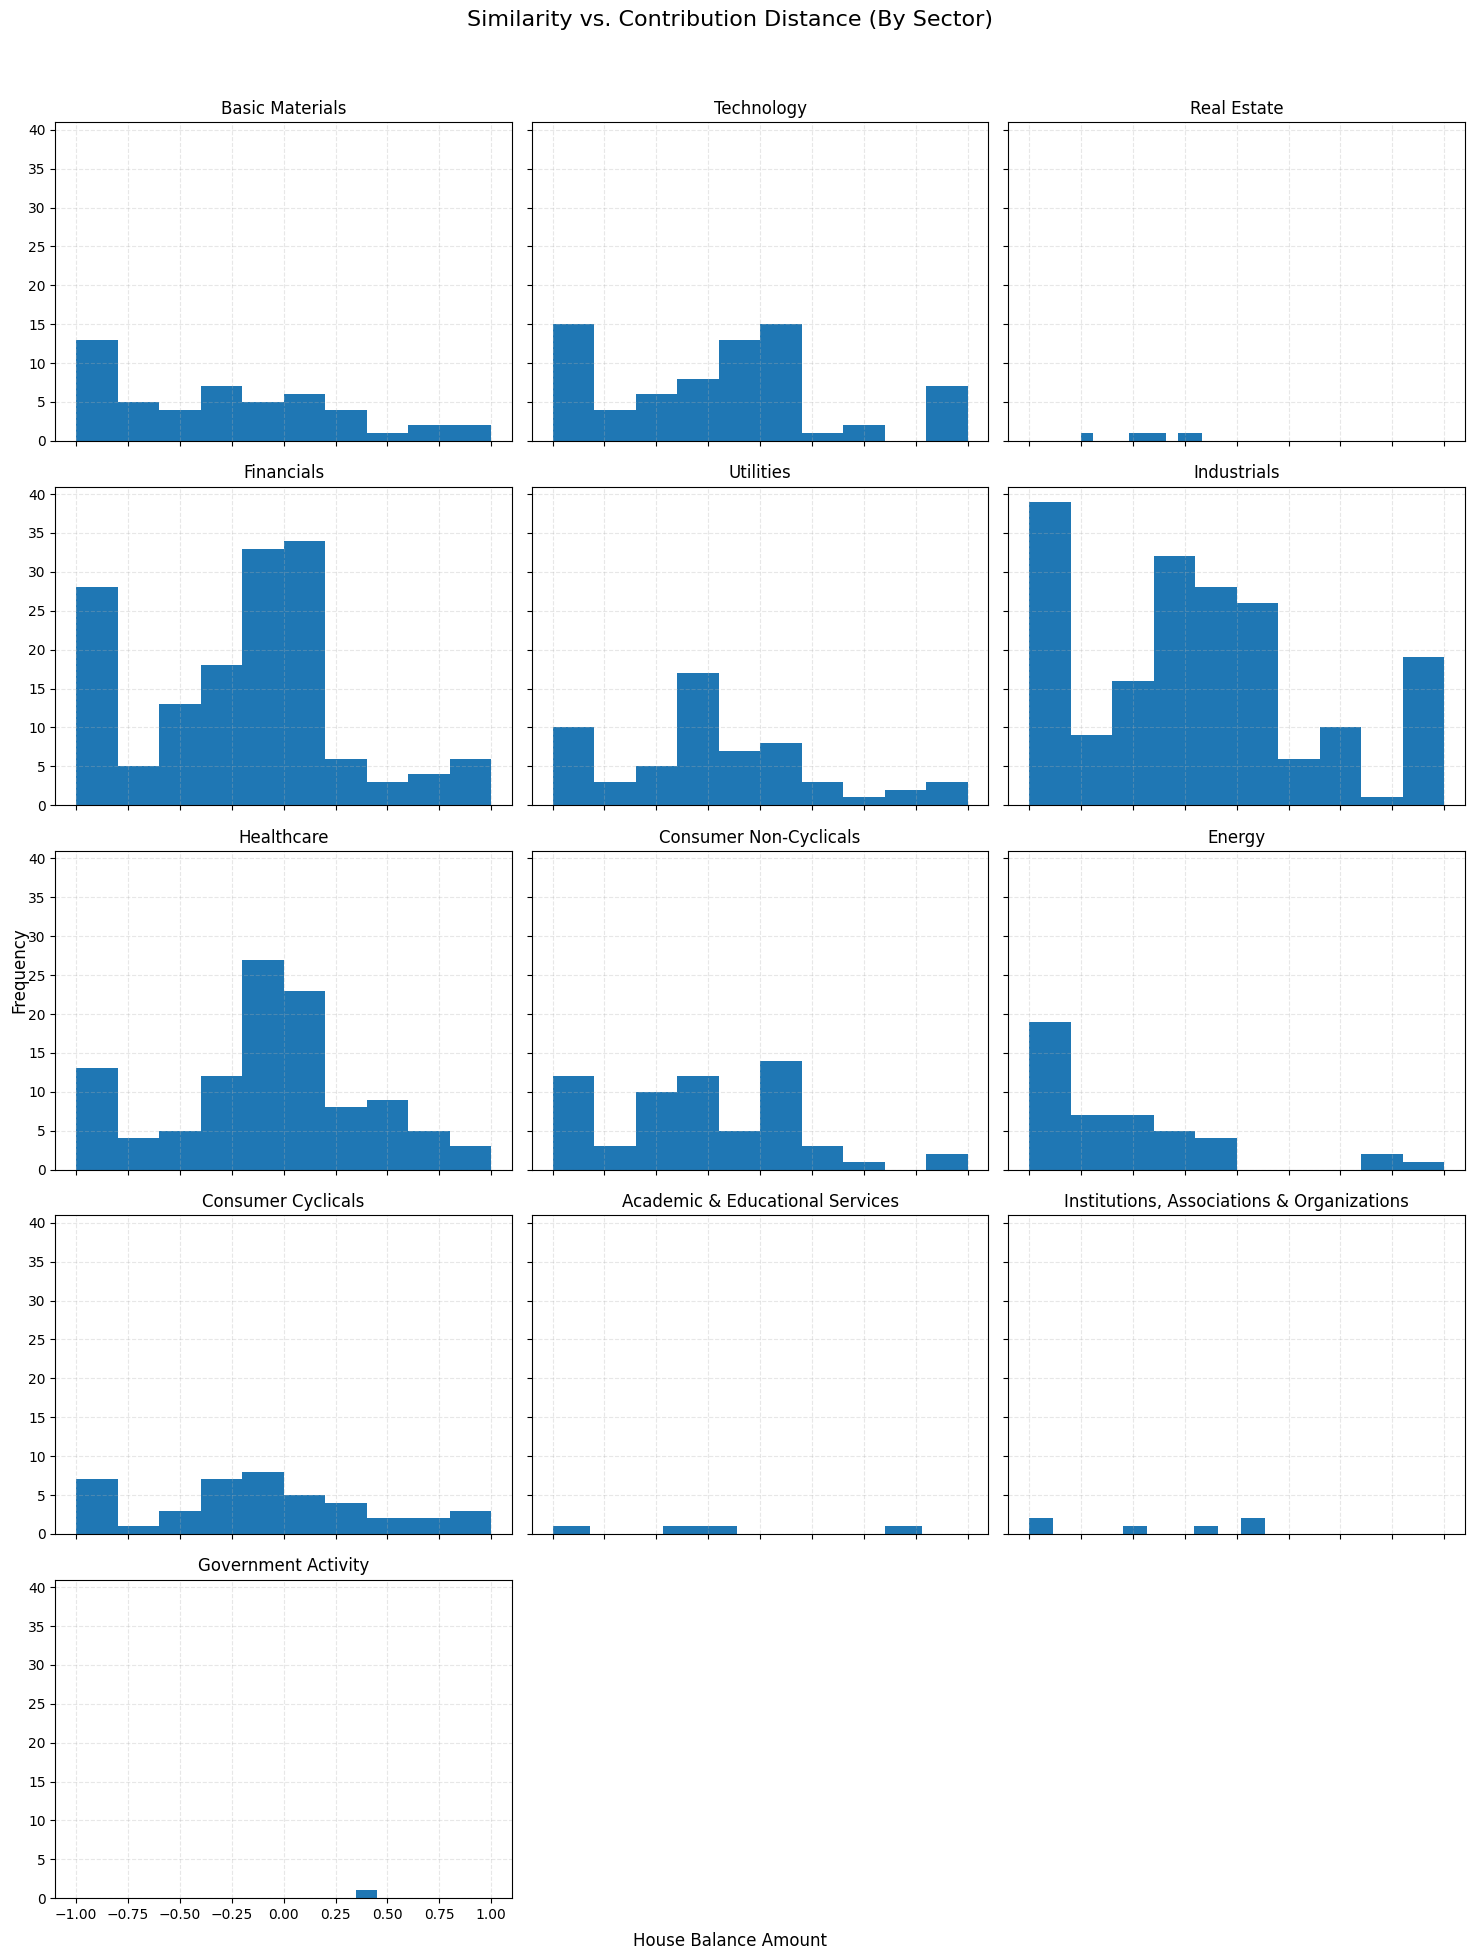

In [108]:
unique_sectors = sector_hedging["Sector"].unique()
n_sectors = len(unique_sectors)

n_cols = 3
n_rows = math.ceil(n_sectors / n_cols)

# Set up the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to 1D for easier iteration

for i, sector in enumerate(unique_sectors):
    ax = axes[i]
    subset = sector_hedging[sector_hedging["Sector"] == sector]
    ax.hist(subset["house_balance_amount"])
    ax.set_title(sector)
    ax.grid(True, linestyle='--', alpha=0.3)

# Set global labels
fig.suptitle("Similarity vs. Contribution Distance (By Sector)", fontsize=16)
fig.supxlabel("House Balance Amount", fontsize=12)
fig.supylabel("Frequency", fontsize=12)

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [109]:
for sector in unique_sectors:
    subset = sector_hedging[sector_hedging["Sector"] == sector]
    print(f"Sector {sector}")
    print(subset["house_balance_amount"].describe())

Sector Basic Materials
count    49.000000
mean     -0.307367
std       0.556881
min      -1.000000
25%      -0.842520
50%      -0.318182
75%       0.017143
max       1.000000
Name: house_balance_amount, dtype: float64
Sector Technology
count    71.000000
mean     -0.202693
std       0.584956
min      -1.000000
25%      -0.665799
50%      -0.130872
75%       0.091673
max       1.000000
Name: house_balance_amount, dtype: float64
Sector Real Estate
count    6.000000
mean    -0.412935
std      0.209128
min     -0.752066
25%     -0.491142
50%     -0.403392
75%     -0.274955
max     -0.166227
Name: house_balance_amount, dtype: float64
Sector Financials
count    150.000000
mean      -0.203127
std        0.508892
min       -1.000000
25%       -0.490737
50%       -0.122634
75%        0.087685
max        1.000000
Name: house_balance_amount, dtype: float64
Sector Utilities
count    59.000000
mean     -0.231259
std       0.514445
min      -1.000000
25%      -0.539782
50%      -0.281553
75%       0